# Q6: Deep Learning vs Classical vs Ensemble ML for DDoS Detection

**Research Question:** Under the network-agnostic **sequence-based** approach, how do the three
model families — **Deep Learning**, **Classical ML**, and **Tree Ensemble** — differ in
DDoS-detection performance, and does any family's advantage hold under the more demanding
time-split, cross-network, and temporal-drift conditions?

**Why it matters:** Deep learning is often advocated for intrusion detection for its capacity to
learn complex temporal patterns; tree ensembles are the workhorses of tabular ML and frequently
generalise well under distribution shift; simpler classical methods (KNN, logistic regression,
SVM) are cheap and interpretable. Knowing which family to reach for — and under which deployment
conditions — has direct practical consequences for DDoS-detection system design.

**Model families:**

| Family | Models |
|--------|--------|
| Deep Learning | GRU, LSTM, RNN, MLP, NN |
| Classical ML | KNN, Logistic Regression, SVM |
| Tree Ensemble | Random Forest, LightGBM, XGBoost |

**Why sequence-based only.** In the SCLDDoS2024 experiments the *component-based* representation
(classify each 1-second observation in isolation) is only available for the non-DL models — the
recurrent and feed-forward networks are trained exclusively on the *sequence-based* representation
(the first *k*=10 components as a multivariate time series). To compare all three families on
**equal footing**, this analysis uses the **sequence-based approach only** (`enable_sequences =
True`). Every model here consumes the same network-agnostic sequence features (packet speed, data
speed, average packet length, source-IP count, inter-component time difference).

**Evaluation regimes.** Each family is evaluated *in-network* (train set = test set) and
*cross-network* (train on one network, test on another) across all four networks (SetA–SetD),
both tasks (Binary/Multiclass), and both split strategies (Random/Time). Because **SetA and SetC
are the same physical network captured ~4 months apart**, the SetA↔SetC pair is excluded from the
cross-network transfer analysis and studied separately as a temporal case study.

The following setup cell imports the required libraries, defines the three model
families and the sequence-only scope, and configures the visual style and output directories used
throughout this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import mannwhitneyu
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = Path('../data/wandb_export_final_hyperparameters.csv')
FIG_DIR   = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
TAB_DIR   = Path('tables');  TAB_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
NETWORKS = ['SetA', 'SetB', 'SetC', 'SetD']
PRIMARY  = 'f1_score'

# ── Three model families ──────────────────────────────────────────────────────
DL_MODELS        = ['gru', 'lstm', 'rnn', 'mlp', 'nn']
CLASSICAL_MODELS = ['knn', 'logistic-regression', 'svm']
ENSEMBLE_MODELS  = ['random-forest', 'lightgbm', 'xgboost']
ALL_MODELS       = DL_MODELS + CLASSICAL_MODELS + ENSEMBLE_MODELS
FAMILIES         = ['Deep Learning', 'Classical', 'Ensemble']

def family_of(m):
    if m in DL_MODELS:        return 'Deep Learning'
    if m in CLASSICAL_MODELS: return 'Classical'
    return 'Ensemble'

FAM_PALETTE  = {'Deep Learning': '#7B1FA2', 'Classical': '#E65100', 'Ensemble': '#2E7D32'}
FAM_SHORT    = {'Deep Learning': 'DL', 'Classical': 'Cls', 'Ensemble': 'Ens'}

# SetA & SetC are the same physical network at different capture times.
# Exclude that pair from the cross-network transfer analysis; it is studied
# separately in the temporal case study (Case Study A).
EXCLUDE_PAIRS = {('SetA', 'SetC'), ('SetC', 'SetA')}

# Pairwise family contrasts used throughout the statistical analysis.
CONTRASTS = [('Deep Learning', 'Classical'),
             ('Deep Learning', 'Ensemble'),
             ('Ensemble',      'Classical')]

Libraries imported and the three model families defined. The sequence-only scope,
the SetA↔SetC exclusion for cross-network transfer, and the three pairwise family contrasts
(DL vs Classical, DL vs Ensemble, Ensemble vs Classical) are configured for the rest of the
notebook.

The next cell loads the results CSV, **restricts it to the sequence-based approach**
(`enable_sequences = True`), drops the auxiliary "Random with same distribution" split, and
reshapes the wide result matrix into long format. Each model is tagged with its family, each
evaluation entry is marked in-network or cross-network, and the SetA↔SetC pair is removed from
the cross-network subset.

In [2]:
raw = pd.read_csv(DATA_PATH, index_col=0)
raw = raw[raw['split'] != 'Random with same distribution']
raw = raw[raw['enable_sequences'] == True]          # sequence-based approach only

metric_cols = [c for c in raw.columns if c.count('/') == 2]
id_vars = ['model', 'task', 'split', 'enable_sequences', 'run_no']

long = raw[id_vars + metric_cols].melt(
    id_vars=id_vars, value_vars=metric_cols,
    var_name='metric_key', value_name='value')
long[['train_set', 'test_set', 'metric']] = long['metric_key'].str.split('/', expand=True)
long = long.drop(columns='metric_key')

long['family']    = long['model'].map(family_of)
long['eval_type'] = np.where(long['train_set'] == long['test_set'],
                             'In-network', 'Cross-network')

f1 = long[long['metric'] == PRIMARY].dropna(subset=['value']).copy()

inset = f1[f1['eval_type'] == 'In-network'].copy()
cross = f1[f1['eval_type'] == 'Cross-network'].copy()
cross = cross[~cross.apply(lambda r: (r['train_set'], r['test_set']) in EXCLUDE_PAIRS, axis=1)]

print(f'Sequence-based F1 rows:   {len(f1):,}')
print(f'  In-network rows:        {len(inset):,}')
print(f'  Cross-network rows:     {len(cross):,}  (SetA<->SetC excluded)')
print()
print('Models present per family:')
for fam in FAMILIES:
    ms = [m for m in ALL_MODELS if family_of(m) == fam and m in f1['model'].unique()]
    print(f'  {fam:<14}: {ms}')

Sequence-based F1 rows:   6,608
  In-network rows:        1,652
  Cross-network rows:     4,130  (SetA<->SetC excluded)

Models present per family:
  Deep Learning : ['gru', 'lstm', 'rnn', 'mlp', 'nn']
  Classical     : ['knn', 'logistic-regression', 'svm']
  Ensemble      : ['random-forest', 'lightgbm', 'xgboost']


The dataset is loaded, filtered to the sequence-based approach, and reshaped into a
long-format DataFrame. Each row is a model's F1 for a specific (run, task, split, train_set,
test_set) setting, tagged with its family. The cross-network subset excludes the SetA↔SetC pair
so that network-transfer effects are not conflated with the same-network temporal drift studied
later.

The next cell averages F1 across training runs for each unique configuration, reducing
run-level noise, and splits the aggregated table into in-network and cross-network views (the
latter again excluding SetA↔SetC).

In [3]:
group_keys = ['model', 'family', 'task', 'split', 'train_set', 'test_set', 'eval_type']

avg = (f1.groupby(group_keys, as_index=False)
         .agg(mean_f1=('value', 'mean'),
              std_f1 =('value', 'std'),
              n_runs =('value', 'count')))

avg_in    = avg[avg['eval_type'] == 'In-network'].copy()
avg_cross = avg[avg['eval_type'] == 'Cross-network'].copy()
avg_cross = avg_cross[~avg_cross.apply(
    lambda r: (r['train_set'], r['test_set']) in EXCLUDE_PAIRS, axis=1)]

print('Averaged rows (all):          ', len(avg))
print('Averaged rows (in-network):   ', len(avg_in))
print('Averaged rows (cross-network):', len(avg_cross))
print()
print('Mean F1 by family and evaluation regime:')
print(avg.assign(regime=avg['eval_type'])
         .groupby(['family', 'regime'])['mean_f1'].mean().unstack('regime').round(4))

Averaged rows (all):           704
Averaged rows (in-network):    176
Averaged rows (cross-network): 440

Mean F1 by family and evaluation regime:
regime         Cross-network  In-network
family                                  
Classical             0.4748      0.7235
Deep Learning         0.5213      0.8091
Ensemble              0.5883      0.8689


The aggregated DataFrame has one row per (model, family, task, split, train_set,
test_set) configuration with its mean F1 across runs. The printed summary previews the headline
pattern the tables and figures develop in detail.

The next cell produces **Table 1**, the top-level three-way summary. For every
combination of evaluation regime, task, and split it reports the mean F1 of each family and the
three pairwise gaps, giving a single reference point before the per-network and per-model
breakdowns.

In [4]:
# ── Table 1: Overall three-way family comparison ─────────────────────────────
records = []
for eval_type, sub in [('In-network', avg_in), ('Cross-network', avg_cross)]:
    for task in ['Binary', 'Multiclass']:
        for split in ['Random split', 'Time split']:
            row = {'Eval type': eval_type, 'Task': task, 'Split': split}
            for fam in FAMILIES:
                v = sub[(sub['family'] == fam) & (sub['task'] == task) &
                        (sub['split'] == split)]['mean_f1'].mean()
                row[fam] = round(v, 4)
            row['DL-Cls']  = round(row['Deep Learning'] - row['Classical'], 4)
            row['DL-Ens']  = round(row['Deep Learning'] - row['Ensemble'],  4)
            row['Ens-Cls'] = round(row['Ensemble']      - row['Classical'], 4)
            records.append(row)

t1 = pd.DataFrame(records)
print('Table 1: Overall three-way family comparison - Mean F1 (sequence-based)')
print(t1.to_string(index=False))
t1.to_csv(TAB_DIR / 'table1_overall_families.csv', index=False)

latex1 = t1.to_latex(index=False, float_format='%.4f',
    caption=(r'Overall mean F1-score by model family (deep learning, classical, ensemble) '
             r'under in-network and cross-network evaluation, sequence-based approach, '
             r'averaged over networks and models within each family. Pairwise columns '
             r'(DL$-$Cls, DL$-$Ens, Ens$-$Cls): positive favours the first family.'),
    label='tab:q6_overall')
(TAB_DIR / 'table1_overall_families.tex').write_text(latex1)
print('\nSaved Table 1.')

Table 1: Overall three-way family comparison - Mean F1 (sequence-based)
    Eval type       Task        Split  Deep Learning  Classical  Ensemble  DL-Cls  DL-Ens  Ens-Cls
   In-network     Binary Random split         0.8852     0.8206    0.9470  0.0646 -0.0618   0.1264
   In-network     Binary   Time split         0.8331     0.7836    0.8536  0.0495 -0.0205   0.0700
   In-network Multiclass Random split         0.7948     0.6618    0.8969  0.1330 -0.1021   0.2351
   In-network Multiclass   Time split         0.7235     0.6279    0.7779  0.0956 -0.0544   0.1500
Cross-network     Binary Random split         0.5885     0.5676    0.6407  0.0209 -0.0522   0.0731
Cross-network     Binary   Time split         0.6022     0.5473    0.6701  0.0549 -0.0679   0.1228
Cross-network Multiclass Random split         0.4642     0.4223    0.5351  0.0419 -0.0709   0.1128
Cross-network Multiclass   Time split         0.4854     0.4128    0.5823  0.0726 -0.0969   0.1695

Saved Table 1.


Table 1 gives the headline: the mean F1 of each family under every regime/task/split,
with the three pairwise gaps. It establishes the overall ordering of the families before the
granular breakdowns that follow.

The next cell builds **Table 2**, a per-network per-task comparison of the three
families' in-network F1, flagging the best family in each setting. It shows whether any family's
lead is consistent across all four network environments or concentrated in specific ones.

In [5]:
# ── Table 2: Per-network three-way comparison (in-network) ───────────────────
records = []
for net in NETWORKS:
    for task in ['Binary', 'Multiclass']:
        row = {'Network': net, 'Task': task}
        for fam in FAMILIES:
            v = avg_in[(avg_in['test_set'] == net) & (avg_in['family'] == fam) &
                       (avg_in['task'] == task)]['mean_f1'].mean()
            row[fam] = round(v, 4)
        row['Best'] = max(FAMILIES, key=lambda f: row[f])
        records.append(row)

t2 = pd.DataFrame(records)
print('Table 2: Per-network three-way comparison (in-network evaluation)')
print(t2.to_string(index=False))
t2.to_csv(TAB_DIR / 'table2_per_network_families.csv', index=False)

latex2 = t2.to_latex(index=False, float_format='%.4f',
    caption=(r'Per-network mean F1-score by model family (in-network evaluation, '
             r'sequence-based approach, averaged over models within each family, splits, '
             r'and tasks per row). Best: highest-scoring family for that network and task.'),
    label='tab:q6_per_network')
(TAB_DIR / 'table2_per_network_families.tex').write_text(latex2)
print('\nSaved Table 2.')

Table 2: Per-network three-way comparison (in-network evaluation)
Network       Task  Deep Learning  Classical  Ensemble     Best
   SetA     Binary         0.6197     0.5581    0.7104 Ensemble
   SetA Multiclass         0.5151     0.4312    0.6588 Ensemble
   SetB     Binary         0.9427     0.8897    0.9634 Ensemble
   SetB Multiclass         0.8782     0.7462    0.9302 Ensemble
   SetC     Binary         0.9076     0.8574    0.9387 Ensemble
   SetC Multiclass         0.7500     0.6908    0.8007 Ensemble
   SetD     Binary         0.9666     0.9032    0.9887 Ensemble
   SetD Multiclass         0.8932     0.7111    0.9600 Ensemble

Saved Table 2.


Table 2 breaks the comparison down per network and task for in-network evaluation,
flagging the winning family in each cell. It reveals whether one family dominates uniformly or
whether the best choice depends on the network environment.

The next cell constructs **Table 3**, ranking all eleven models by in-network F1 and
reporting, per model, the random/time split performance, the cross-network score, and the two
key robustness gaps: the *time-split drop* (random $-$ time) and the *transfer drop* (in-network
$-$ cross-network).

In [6]:
# ── Table 3: Per-model ranking (family-tagged) ───────────────────────────────
records = []
for model in ALL_MODELS:
    if model not in avg_in['model'].unique():
        continue
    fam       = family_of(model)
    in_all    = avg_in[avg_in['model'] == model]['mean_f1'].mean()
    in_rand   = avg_in[(avg_in['model'] == model) &
                       (avg_in['split'] == 'Random split')]['mean_f1'].mean()
    in_time   = avg_in[(avg_in['model'] == model) &
                       (avg_in['split'] == 'Time split')]['mean_f1'].mean()
    cross_all = avg_cross[avg_cross['model'] == model]['mean_f1'].mean()
    records.append({
        'Model':            model,
        'Family':           fam,
        'In-net (overall)': round(in_all,    4),
        'In-net (rand)':    round(in_rand,   4),
        'In-net (time)':    round(in_time,   4),
        'Cross-net':        round(cross_all, 4),
        'Time-split drop':  round(in_rand - in_time,   4),
        'Transfer drop':    round(in_all  - cross_all, 4),
    })

t3 = (pd.DataFrame(records)
        .sort_values('In-net (overall)', ascending=False)
        .reset_index(drop=True))
print('Table 3: Per-model F1 ranking (sorted by in-network F1)')
print(t3.to_string(index=False))
t3.to_csv(TAB_DIR / 'table3_per_model_ranking.csv', index=False)

latex3 = t3.to_latex(index=False, float_format='%.4f',
    caption=(r'Per-model mean F1-score (sequence-based): in-network (overall, random, time), '
             r'cross-network, time-split drop (random $-$ time), and transfer drop '
             r'(in-network $-$ cross-network). Models tagged by family.'),
    label='tab:q6_per_model')
(TAB_DIR / 'table3_per_model_ranking.tex').write_text(latex3)
print('\nSaved Table 3.')

Table 3: Per-model F1 ranking (sorted by in-network F1)
              Model        Family  In-net (overall)  In-net (rand)  In-net (time)  Cross-net  Time-split drop  Transfer drop
           lightgbm      Ensemble            0.8717         0.9233         0.8202     0.6131           0.1031         0.2586
            xgboost      Ensemble            0.8698         0.9214         0.8183     0.5993           0.1031         0.2705
      random-forest      Ensemble            0.8650         0.9212         0.8089     0.6087           0.1123         0.2564
                gru Deep Learning            0.8396         0.8843         0.7948     0.5979           0.0895         0.2417
                rnn Deep Learning            0.8327         0.8751         0.7902     0.5853           0.0849         0.2473
               lstm Deep Learning            0.8291         0.8732         0.7850     0.4992           0.0882         0.3299
                knn     Classical            0.7833         0.8054   

Table 3 ranks every model by in-network F1 and exposes the two robustness gaps side by
side. Reading the *transfer drop* column against the family tags shows which family holds up best
when the model must generalise to an unseen network.

The next cell runs the **deep statistical comparison**. For every
(evaluation regime, task, split) stratum it performs all three pairwise family contrasts,
comparing the F1 of *every model×network configuration* in one family against the other
(n ≈ 12–20 per family). Tests use **Mann-Whitney U** with **Cohen's d** effect sizes, and because
three contrasts are tested per stratum, p-values are **Holm-corrected** within each stratum to
control the family-wise error rate.

Pooling across networks is deliberate: stratifying tests *per network* would leave only 3 models
in the Classical and Ensemble families, and Mann-Whitney U on 3 vs 3 samples has a minimum
attainable two-sided p of 0.1 — it can never reach significance regardless of effect size.
Per-network differences are still reported descriptively as effect sizes in Figure 5. The
per-stratum results are stored in `stat_df` and summarised in **Table 4**.

In [7]:
# ── Table 4: Pairwise family statistical tests (Mann-Whitney U + Cohen's d) ──
def cohens_d_ind(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return float('nan')
    pooled = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 +
                      (nb - 1) * b.std(ddof=1) ** 2) / (na + nb - 2))
    return (a.mean() - b.mean()) / (pooled + 1e-12)

def holm(pvals):
    '''Holm step-down adjusted p-values, preserving input order.'''
    pvals = np.asarray(pvals, float)
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (m - rank) * pvals[idx])
        adj[idx] = min(running, 1.0)
    return adj

records = []
for eval_type, sub_avg in [('In-network', avg_in), ('Cross-network', avg_cross)]:
    for task in ['Binary', 'Multiclass']:
        for split in ['Random split', 'Time split']:
            base = sub_avg[(sub_avg['task'] == task) & (sub_avg['split'] == split)]
            stratum, pvals = [], []
            for fa, fb in CONTRASTS:
                va = base[base['family'] == fa]['mean_f1'].values   # all model x network configs
                vb = base[base['family'] == fb]['mean_f1'].values
                if len(va) < 2 or len(vb) < 2:
                    continue
                try:
                    _, p = mannwhitneyu(va, vb, alternative='two-sided')
                except ValueError:
                    p = 1.0
                stratum.append({
                    'eval_type': eval_type, 'task': task, 'split': split,
                    'contrast': f'{FAM_SHORT[fa]} vs {FAM_SHORT[fb]}',
                    'n_a': len(va), 'n_b': len(vb),
                    'mean_a': va.mean(), 'mean_b': vb.mean(),
                    'diff': va.mean() - vb.mean(),
                    'cohens_d': cohens_d_ind(va, vb), 'p_raw': p})
                pvals.append(p)
            for r, pa in zip(stratum, holm(pvals)):
                r['p_holm'] = pa
                r['significant'] = bool(pa < 0.05)
            records.extend(stratum)

stat_df = pd.DataFrame(records)
stat_df.to_csv(TAB_DIR / 'table4_statistical_tests_full.csv', index=False)

# Table 4 = full per-stratum detail (12 strata x 3 contrasts)
t4 = stat_df[['eval_type', 'task', 'split', 'contrast',
              'diff', 'cohens_d', 'p_holm', 'significant']].round(4)
print('Table 4: Pairwise family tests (Mann-Whitney U + Cohen\'s d, Holm-corrected)')
print(t4.to_string(index=False))
t4.to_csv(TAB_DIR / 'table4_statistical_tests.csv', index=False)

latex4 = t4.to_latex(index=False, float_format='%.4f',
    caption=(r'Pairwise family statistical comparison (sequence-based). Mann-Whitney U over all '
             r'model$\times$network configurations, Holm-corrected across the three contrasts '
             r'within each (regime, task, split) stratum; Cohen''s d effect size. diff: signed '
             r'F1 gap (first $-$ second family).'),
    label='tab:q6_stats')
(TAB_DIR / 'table4_statistical_tests.tex').write_text(latex4)
print('\nSaved Table 4 (+ full per-stratum CSV).')

Table 4: Pairwise family tests (Mann-Whitney U + Cohen's d, Holm-corrected)
    eval_type       task        split   contrast    diff  cohens_d  p_holm  significant
   In-network     Binary Random split  DL vs Cls  0.0645    0.4898  0.1080        False
   In-network     Binary Random split  DL vs Ens -0.0618   -0.6138  0.1080        False
   In-network     Binary Random split Ens vs Cls  0.1263    1.1395  0.0128         True
   In-network     Binary   Time split  DL vs Cls  0.0496    0.2865  0.0820        False
   In-network     Binary   Time split  DL vs Ens -0.0205   -0.1135  0.2351        False
   In-network     Binary   Time split Ens vs Cls  0.0701    0.4054  0.0497         True
   In-network Multiclass Random split  DL vs Cls  0.1330    0.9469  0.0216         True
   In-network Multiclass Random split  DL vs Ens -0.1021   -0.8962  0.0216         True
   In-network Multiclass Random split Ens vs Cls  0.2351    2.0613  0.0005         True
   In-network Multiclass   Time split  DL vs

Table 4 reports, for each (regime, task, split) stratum, the signed F1 gap, Cohen's d,
Holm-adjusted p-value, and significance flag of every pairwise family contrast. The
Ensemble-vs-Classical and Ensemble-vs-DL gaps carry the largest effect sizes; the full detail is
saved to `table4_statistical_tests_full.csv`.

The next cell produces **Figure 1**, the primary visual comparison: F1 distributions of
the three families per network and task under in-network evaluation, annotated with the share of
pairwise contrasts that are significant in each setting.

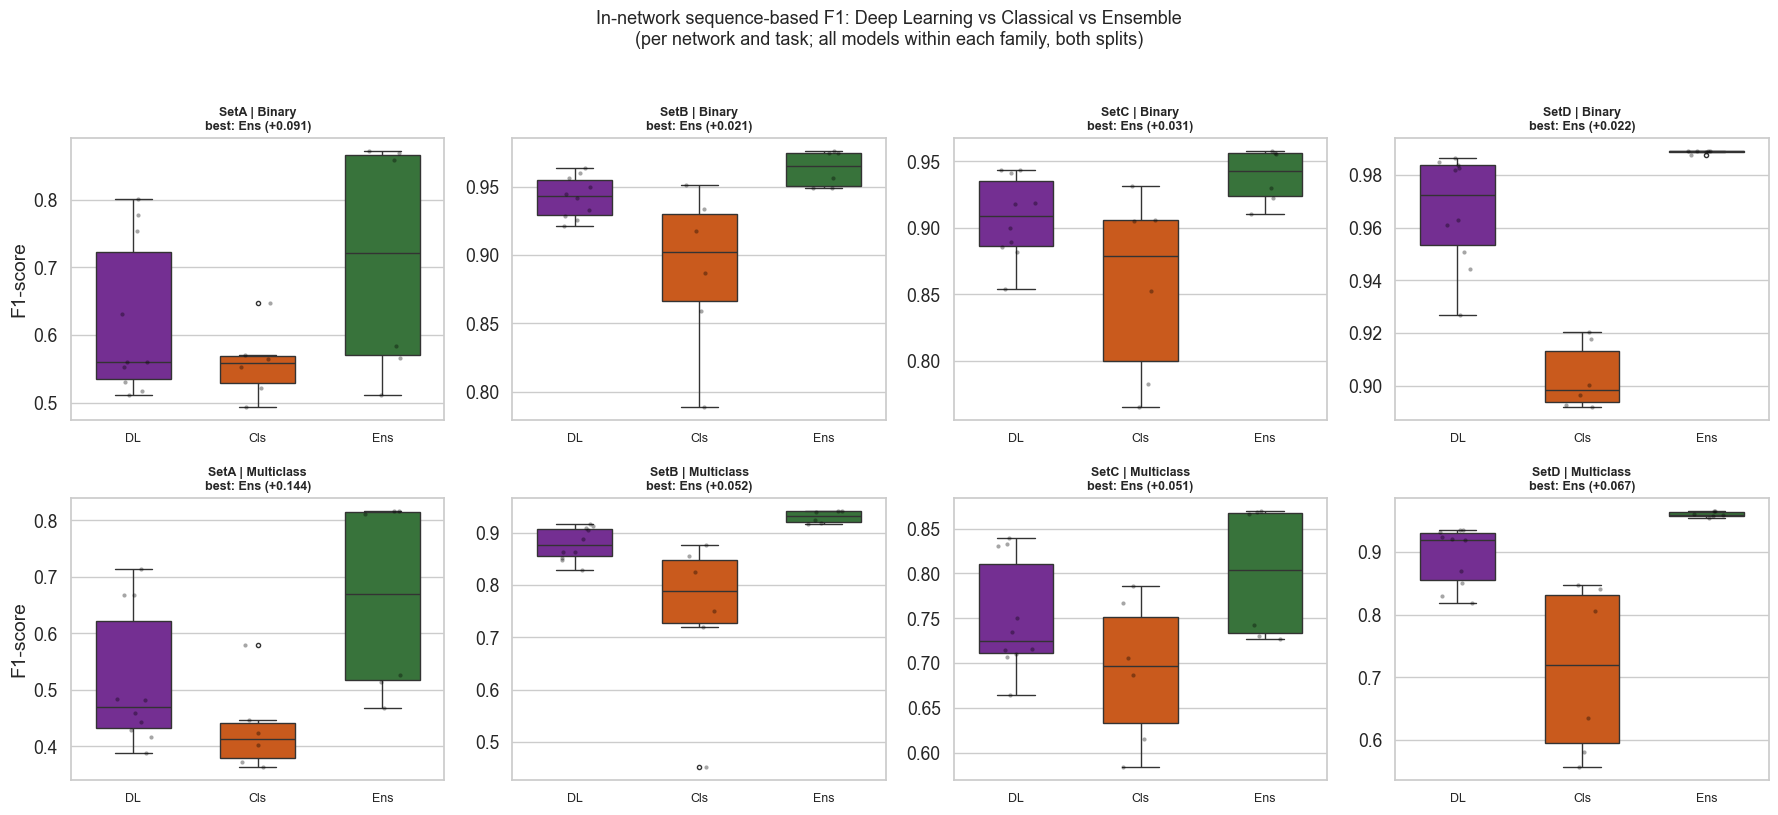

In [8]:
# ── Figure 1: Three-way boxplots per network x task (in-network) ─────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
for col, net in enumerate(NETWORKS):
    for row, task in enumerate(['Binary', 'Multiclass']):
        ax = axes[row, col]
        sub = avg_in[(avg_in['test_set'] == net) & (avg_in['task'] == task)]
        sns.boxplot(data=sub, x='family', y='mean_f1', hue='family',
                    palette=FAM_PALETTE, order=FAMILIES, ax=ax,
                    width=0.6, fliersize=3, legend=False)
        sns.stripplot(data=sub, x='family', y='mean_f1', order=FAMILIES,
                      ax=ax, color='black', size=3, alpha=0.35, jitter=0.15)
        means = {f: sub[sub['family'] == f]['mean_f1'].mean() for f in FAMILIES}
        best = max(means, key=means.get)
        margin = means[best] - sorted(means.values())[-2]
        ax.set_title(f'{net} | {task}\nbest: {FAM_SHORT[best]} (+{margin:.3f})',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('F1-score' if col == 0 else '')
        ax.set_xticklabels(['DL', 'Cls', 'Ens'], fontsize=9)
fig.suptitle('In-network sequence-based F1: Deep Learning vs Classical vs Ensemble\n'
             '(per network and task; all models within each family, both splits)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_boxplot_families_innet.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig1_boxplot_families_innet.png', dpi=150, bbox_inches='tight')
plt.show()

Figure 1 shows the F1 distribution of each family per network and task. The overlaid
points expose within-family spread, and the per-panel annotation reports how often the pairwise
family differences are statistically significant in that setting.

The next cell produces **Figure 2**, a per-model × per-network F1 heatmap with rows
grouped and colour-coded by family. It reveals which individual models carry their family's
performance and how consistent each model is across the four networks.

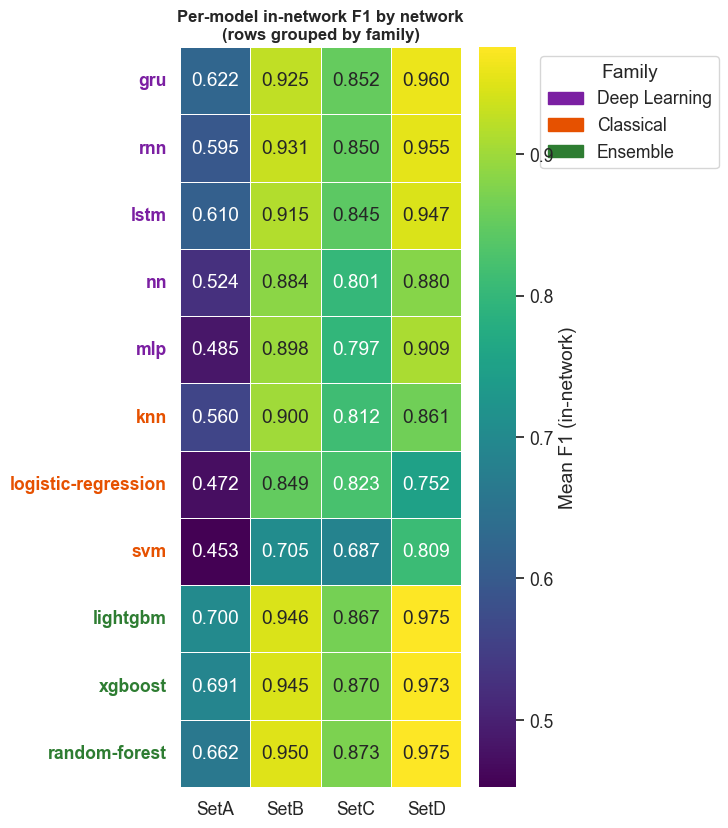

In [9]:
# ── Figure 2: Per-model x per-network in-network F1 heatmap ──────────────────
model_net = (avg_in.groupby(['model', 'test_set'], as_index=False)['mean_f1'].mean()
                   .pivot(index='model', columns='test_set', values='mean_f1')
                   .reindex(columns=NETWORKS))

row_order = []
for fam in FAMILIES:
    fam_models = [m for m in ALL_MODELS if family_of(m) == fam and m in model_net.index]
    fam_models = model_net.loc[fam_models].mean(axis=1).sort_values(ascending=False).index.tolist()
    row_order += fam_models
model_net = model_net.reindex(row_order)

fig, ax = plt.subplots(figsize=(7.5, 8.5))
sns.heatmap(model_net, annot=True, fmt='.3f', cmap='viridis',
            cbar_kws={'label': 'Mean F1 (in-network)'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_title('Per-model in-network F1 by network\n(rows grouped by family)',
             fontsize=12, fontweight='bold')
for lbl in ax.get_yticklabels():
    lbl.set_color(FAM_PALETTE[family_of(lbl.get_text())])
    lbl.set_fontweight('bold')
handles = [plt.Rectangle((0, 0), 1, 1, color=FAM_PALETTE[f]) for f in FAMILIES]
ax.legend(handles, FAMILIES, title='Family', loc='upper left',
          bbox_to_anchor=(1.25, 1.0), frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_heatmap_model_network.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig2_heatmap_model_network.png', dpi=150, bbox_inches='tight')
plt.show()

Figure 2 maps every model's in-network F1 across the four networks, with row labels
coloured by family. It distinguishes models that are uniformly strong from those whose
performance is network-dependent, and shows how each family's members cluster.

The next cell produces **Figure 3**, contrasting each family's **in-network** and
**cross-network** F1 under both splits. This is the transfer story: how much of each family's
in-network performance survives deployment on an unseen network.

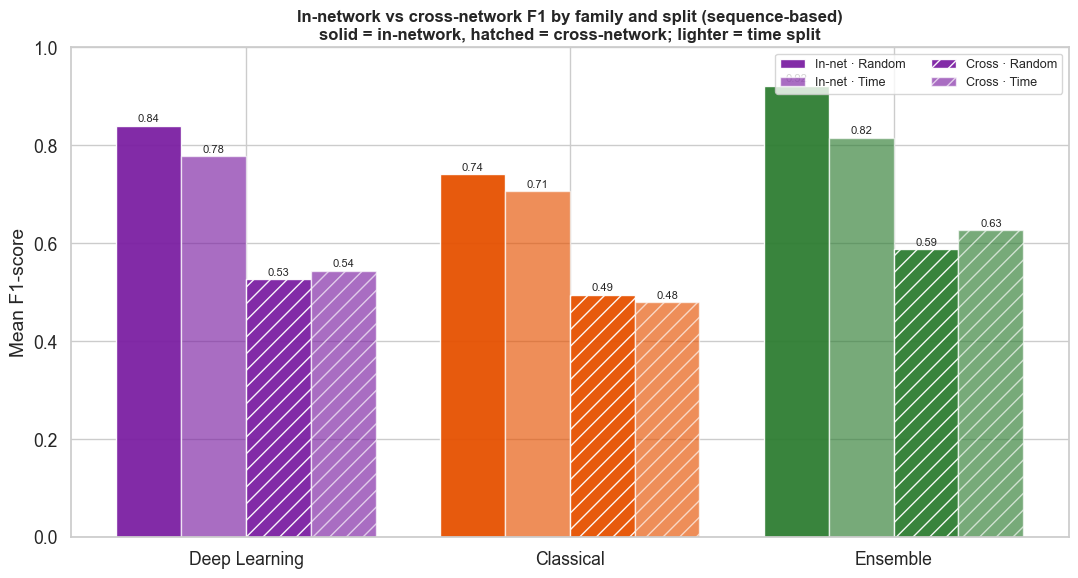

In [10]:
# ── Figure 3: In-network vs cross-network per family (grouped bars) ──────────
fig, ax = plt.subplots(figsize=(11, 6))
bar_specs = [('In-net · Random', avg_in,    'Random split', 0),
             ('In-net · Time',   avg_in,    'Time split',   1),
             ('Cross · Random',  avg_cross, 'Random split', 2),
             ('Cross · Time',    avg_cross, 'Time split',   3)]
x = np.arange(len(FAMILIES)); width = 0.2
hatches = ['', '', '//', '//']
alphas  = [0.95, 0.65, 0.95, 0.65]
for label, src, split, k in bar_specs:
    vals = [src[(src['family'] == fam) & (src['split'] == split)]['mean_f1'].mean()
            for fam in FAMILIES]
    bars = ax.bar(x + (k - 1.5) * width, vals, width, label=label,
                  color=[FAM_PALETTE[f] for f in FAMILIES],
                  alpha=alphas[k], hatch=hatches[k], edgecolor='white')
    for xi, v in zip(x + (k - 1.5) * width, vals):
        ax.text(xi, v + 0.008, f'{v:.2f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(FAMILIES)
ax.set_ylabel('Mean F1-score')
ax.set_title('In-network vs cross-network F1 by family and split (sequence-based)\n'
             'solid = in-network, hatched = cross-network; lighter = time split',
             fontsize=12, fontweight='bold')
ax.legend(ncol=2, fontsize=9, loc='upper right')
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_innet_vs_cross_families.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig3_innet_vs_cross_families.png', dpi=150, bbox_inches='tight')
plt.show()

Figure 3 places each family's in-network and cross-network F1 side by side for both
splits. The height gap between the solid and hatched bars is the transfer drop; comparing that
gap across families shows which family generalises best to unseen networks.

The next cell produces **Figure 4**, isolating the **split-strategy effect**: the F1
drop from random to time split for each family, shown separately for in-network and
cross-network evaluation. A larger drop means the family's reported performance is more inflated
by the optimistic random split.

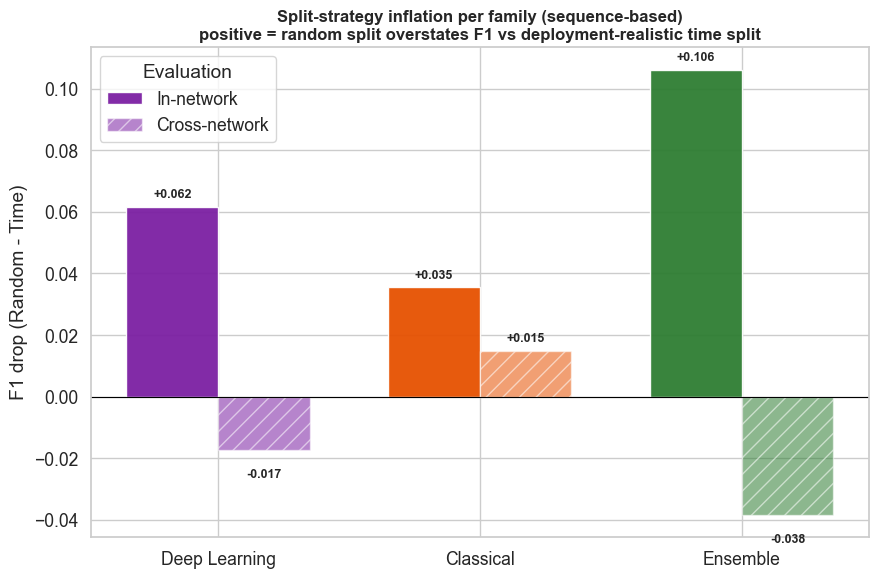

In [11]:
# ── Figure 4: Random -> Time split degradation per family ────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(FAMILIES)); width = 0.35
for k, (label, src) in enumerate([('In-network', avg_in), ('Cross-network', avg_cross)]):
    drops = []
    for fam in FAMILIES:
        r = src[(src['family'] == fam) & (src['split'] == 'Random split')]['mean_f1'].mean()
        t = src[(src['family'] == fam) & (src['split'] == 'Time split')]['mean_f1'].mean()
        drops.append(r - t)
    bars = ax.bar(x + (k - 0.5) * width, drops, width, label=label,
                  color=[FAM_PALETTE[f] for f in FAMILIES],
                  alpha=0.95 if k == 0 else 0.55, edgecolor='white',
                  hatch='' if k == 0 else '//')
    for xi, v in zip(x + (k - 0.5) * width, drops):
        ax.text(xi, v + (0.002 if v >= 0 else -0.006), f'{v:+.3f}',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=9, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(FAMILIES)
ax.set_ylabel('F1 drop (Random - Time)')
ax.set_title('Split-strategy inflation per family (sequence-based)\n'
             'positive = random split overstates F1 vs deployment-realistic time split',
             fontsize=12, fontweight='bold')
ax.legend(title='Evaluation')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_split_degradation_families.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig4_split_degradation_families.png', dpi=150, bbox_inches='tight')
plt.show()

Figure 4 quantifies how much each family's F1 falls when moving from the optimistic
random split to the deployment-realistic time split, for both evaluation regimes. Families with
taller bars are more prone to over-optimistic reporting under random splitting.

The next cell produces **Figure 5**, the effect-size view: signed **Cohen's d** for each
pairwise family contrast per network, shown as two heatmaps (in-network and cross-network). It
summarises not just whether families differ but by how much, and in which direction, across
environments.

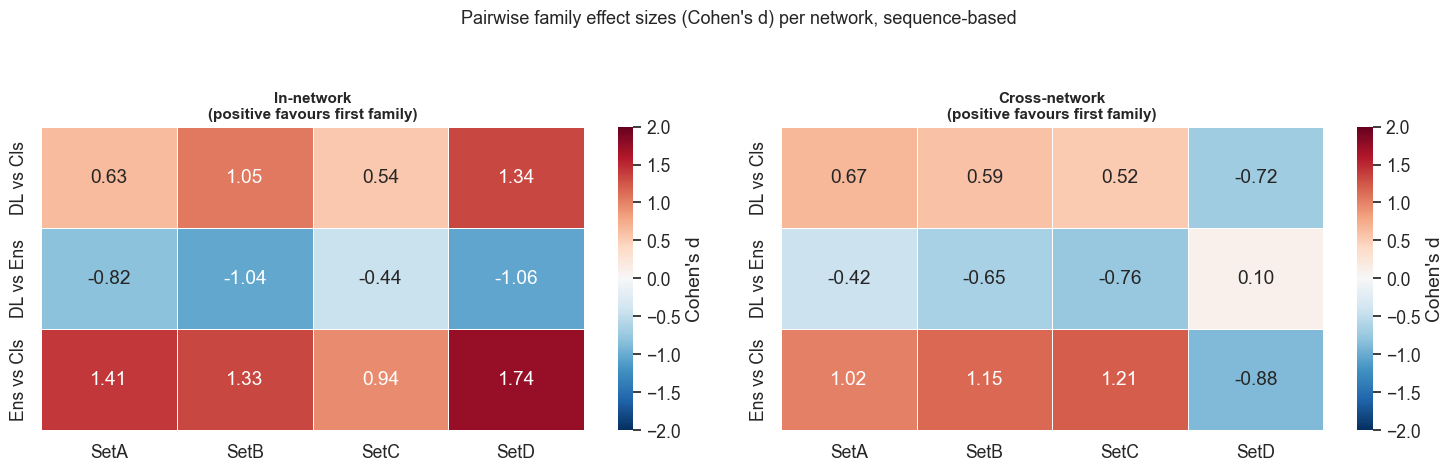

In [12]:
# ── Figure 5: Pairwise Cohen's d per network (in-net & cross-net) ────────────
# Descriptive per-network effect sizes over all model x (task, split) configs.
contrast_order = [f'{FAM_SHORT[a]} vs {FAM_SHORT[b]}' for a, b in CONTRASTS]

def per_network_d(src, net_key):
    rows = []
    for net in NETWORKS:
        base = src[src[net_key] == net]
        for fa, fb in CONTRASTS:
            va = base[base['family'] == fa]['mean_f1'].values
            vb = base[base['family'] == fb]['mean_f1'].values
            rows.append({'contrast': f'{FAM_SHORT[fa]} vs {FAM_SHORT[fb]}',
                         'network': net, 'cohens_d': cohens_d_ind(va, vb)})
    return (pd.DataFrame(rows)
              .pivot(index='contrast', columns='network', values='cohens_d')
              .reindex(index=contrast_order, columns=NETWORKS))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, regime, src, net_key in [
        (axes[0], 'In-network',    avg_in,    'test_set'),
        (axes[1], 'Cross-network', avg_cross, 'train_set')]:
    piv = per_network_d(src, net_key)
    sns.heatmap(piv, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-2, vmax=2, cbar_kws={'label': "Cohen's d"}, ax=ax,
                linewidths=0.5, linecolor='white')
    ax.set_title(f'{regime}\n(positive favours first family)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
fig.suptitle('Pairwise family effect sizes (Cohen\'s d) per network, sequence-based',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_cohens_d_families.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig5_cohens_d_families.png', dpi=150, bbox_inches='tight')
plt.show()

Figure 5 shows the signed Cohen's d for each family pair per network, in-network (left)
and cross-network (right). Colour intensity conveys effect magnitude and direction, exposing how
the pairwise ordering of families can flip between the two regimes.

## Case Study A: Temporal degradation over a four-month gap (SetA → SetC)

SetA and SetC are the **same physical network captured at different times** — SetA's capture ends
2023-04-27, SetC spans 2023-08-25 → 2023-11-19, a gap of roughly **four months**. Training on
SetA and testing on SetC is therefore not a network transfer but a **natural, extreme time
split** that isolates pure temporal drift from network-domain shift — precisely the situation a
model faces when trained today and expected to keep detecting attacks months later.

We build a **temporal-generalisation ladder** of increasing realism and ask which family degrades
most gracefully:

1. **SetA, random split (in-network)** — most optimistic; future traffic can leak into training.
2. **SetA, time split (in-network)** — deployment-realistic, short train/test gap.
3. **SetA → SetC, time split** — same network, ~4-month gap: real long-horizon deployment.

The next cell assembles the ladder per family and reports each family's temporal drop.

In [13]:
# ── Case Study A: SetA -> SetC temporal ladder (sequence-based) ──────────────
tempo = f1[(f1['train_set'] == 'SetA') & (f1['test_set'].isin(['SetA', 'SetC']))].copy()
tempo_avg = (tempo.groupby(['model', 'family', 'task', 'split', 'test_set'],
                           as_index=False)['value'].mean()
                  .rename(columns={'value': 'mean_f1'}))

def _rung(fam, split, test_set):
    return tempo_avg[(tempo_avg['family'] == fam) & (tempo_avg['split'] == split) &
                     (tempo_avg['test_set'] == test_set)]['mean_f1'].mean()

rows = []
for fam in FAMILIES:
    r_in  = _rung(fam, 'Random split', 'SetA')
    t_in  = _rung(fam, 'Time split',   'SetA')
    t_gap = _rung(fam, 'Time split',   'SetC')
    rows.append({
        'Family': fam,
        'Random in-net':      round(r_in,  4),
        'Time in-net':        round(t_in,  4),
        'SetA->SetC (time)':  round(t_gap, 4),
        'Temporal drop':      round(t_in  - t_gap, 4),
        'Total drop':         round(r_in  - t_gap, 4),
    })
csa = pd.DataFrame(rows)
print('Case Study A: temporal-generalisation ladder, SetA -> SetC (~4-month gap)')
print(csa.to_string(index=False))
csa.to_csv(TAB_DIR / 'cs_temporal_setA_setC_families.csv', index=False)

latex_csa = csa.to_latex(index=False, float_format='%.4f',
    caption=(r'Case Study A --- temporal generalisation over a four-month gap on the same '
             r'physical network (SetA $\rightarrow$ SetC), sequence-based. Temporal drop = '
             r'time in-net $-$ SetA$\to$SetC; total drop = random in-net $-$ SetA$\to$SetC.'),
    label='tab:q6_cs_temporal')
(TAB_DIR / 'cs_temporal_setA_setC_families.tex').write_text(latex_csa)
print('\nSaved Case Study A table.')

Case Study A: temporal-generalisation ladder, SetA -> SetC (~4-month gap)
       Family  Random in-net  Time in-net  SetA->SetC (time)  Temporal drop  Total drop
Deep Learning         0.6541       0.4807             0.4654         0.0153      0.1887
    Classical         0.5292       0.4602             0.3785         0.0817      0.1507
     Ensemble         0.8409       0.5283             0.4880         0.0403      0.3529

Saved Case Study A table.


The table gives each family's position on the temporal ladder and its temporal drop over
the four-month gap. Comparing the *SetA→SetC (time)* column across families identifies which
family is most robust to long-horizon temporal drift on a fixed network.

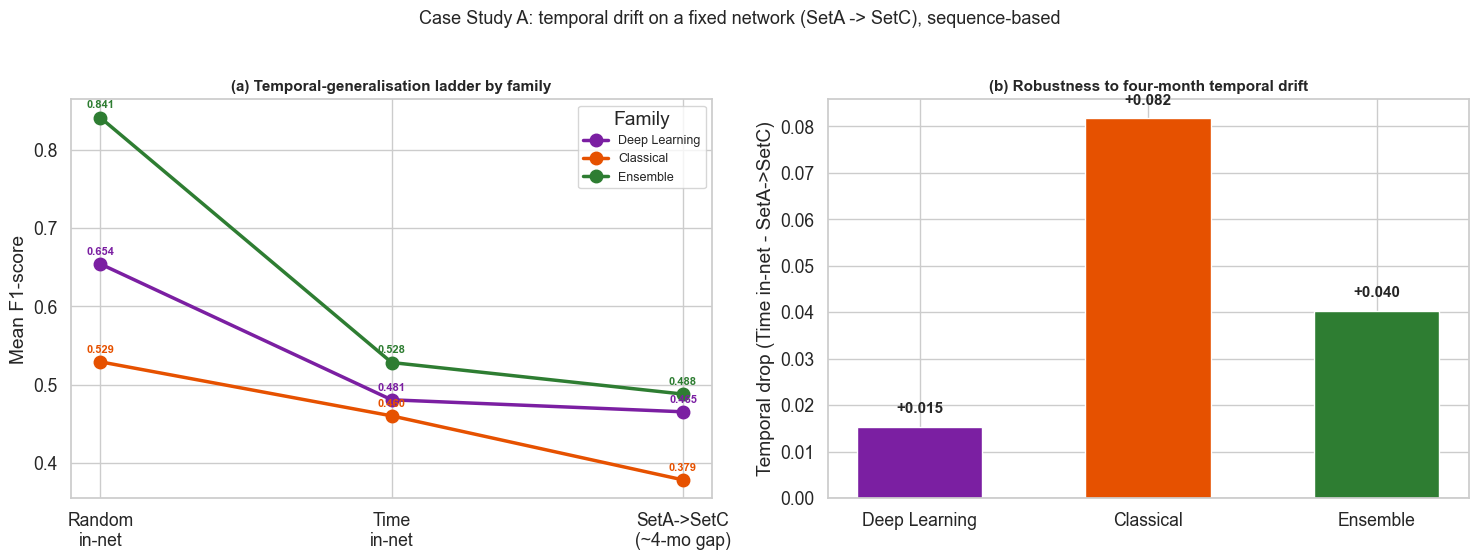

In [14]:
# ── Case Study A figure: ladder + temporal drop ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel (a): the ladder as connected lines, one per family
ax = axes[0]
rungs = ['Random in-net', 'Time in-net', 'SetA->SetC (time)']
xs = np.arange(len(rungs))
for _, r in csa.iterrows():
    ax.plot(xs, [r[c] for c in rungs], marker='o', markersize=9, lw=2.5,
            color=FAM_PALETTE[r['Family']], label=r['Family'])
    for xi, c in zip(xs, rungs):
        ax.text(xi, r[c] + 0.012, f"{r[c]:.3f}", ha='center', fontsize=8,
                color=FAM_PALETTE[r['Family']], fontweight='bold')
ax.set_xticks(xs)
ax.set_xticklabels(['Random\nin-net', 'Time\nin-net', 'SetA->SetC\n(~4-mo gap)'])
ax.set_ylabel('Mean F1-score')
ax.set_title('(a) Temporal-generalisation ladder by family', fontsize=11, fontweight='bold')
ax.legend(title='Family', fontsize=9)

# Panel (b): temporal drop (time in-net -> SetA->SetC) per family
ax = axes[1]
drops = csa.set_index('Family')['Temporal drop'].reindex(FAMILIES)
bars = ax.bar(FAMILIES, drops.values, width=0.55,
              color=[FAM_PALETTE[f] for f in FAMILIES], edgecolor='white')
for b, v in zip(bars, drops.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.003, f'{v:+.3f}',
            ha='center', fontsize=11, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Temporal drop (Time in-net - SetA->SetC)')
ax.set_title('(b) Robustness to four-month temporal drift', fontsize=11, fontweight='bold')

fig.suptitle('Case Study A: temporal drift on a fixed network (SetA -> SetC), sequence-based',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_cs_temporal_setA_setC.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_cs_temporal_setA_setC.png', dpi=150, bbox_inches='tight')
plt.show()

Panel (a) traces each family down the ladder of increasing realism; panel (b) isolates
the four-month temporal drop. Together they show how much of the optimistic in-network F1 is lost
to pure temporal drift and which family absorbs that loss best.

## Case Study B: Cross-network deployment from the strongest source (SetC → SetB, SetD)

A deployed detector is typically trained on one well-instrumented network and then rolled out to
others. This case study fixes the training source to **SetC** — the strongest cross-network
source identified in the wider study — and measures how each family transfers to two genuinely
different networks, **SetB** and **SetD**. SetA is excluded as a target because it is the same
physical network as SetC.

The next cell assembles the SetC in-network baseline alongside the SetC→SetB and SetC→SetD
transfers per family, using the deployment-realistic **time split**.

In [15]:
# ── Case Study B: SetC -> {SetB, SetD} deployment (time split, sequence-based) ─
dep = f1[(f1['train_set'] == 'SetC') &
         (f1['test_set'].isin(['SetC', 'SetB', 'SetD'])) &
         (f1['split'] == 'Time split')].copy()
dep_avg = (dep.groupby(['model', 'family', 'test_set'], as_index=False)['value'].mean()
              .rename(columns={'value': 'mean_f1'}))

def _dep(fam, test_set):
    return dep_avg[(dep_avg['family'] == fam) &
                   (dep_avg['test_set'] == test_set)]['mean_f1'].mean()

rows = []
for fam in FAMILIES:
    base = _dep(fam, 'SetC')
    b    = _dep(fam, 'SetB')
    d    = _dep(fam, 'SetD')
    rows.append({
        'Family': fam,
        'SetC in-net':   round(base, 4),
        'SetC->SetB':    round(b, 4),
        'SetC->SetD':    round(d, 4),
        'Mean deploy':   round(np.mean([b, d]), 4),
        'Deploy drop':   round(base - np.mean([b, d]), 4),
    })
csb = pd.DataFrame(rows)
print('Case Study B: cross-network deployment from SetC (time split)')
print(csb.to_string(index=False))
csb.to_csv(TAB_DIR / 'cs_deploy_setC_families.csv', index=False)

latex_csb = csb.to_latex(index=False, float_format='%.4f',
    caption=(r'Case Study B --- cross-network deployment from the strongest source SetC '
             r'to SetB and SetD (time split, sequence-based). Deploy drop = SetC in-net $-$ '
             r'mean of the two transfers. SetA excluded (same network as SetC).'),
    label='tab:q6_cs_deploy')
(TAB_DIR / 'cs_deploy_setC_families.tex').write_text(latex_csb)
print('\nSaved Case Study B table.')

Case Study B: cross-network deployment from SetC (time split)
       Family  SetC in-net  SetC->SetB  SetC->SetD  Mean deploy  Deploy drop
Deep Learning       0.7996      0.7447      0.5977       0.6712       0.1284
    Classical       0.7439      0.6026      0.6052       0.6039       0.1400
     Ensemble       0.8270      0.9321      0.6901       0.8111       0.0158

Saved Case Study B table.


The table contrasts each family's SetC in-network baseline with its transfer to SetB and
SetD. The *deploy drop* column measures how much performance is lost on rollout; a smaller drop
means the family is more dependable when deployed to networks unseen during training.

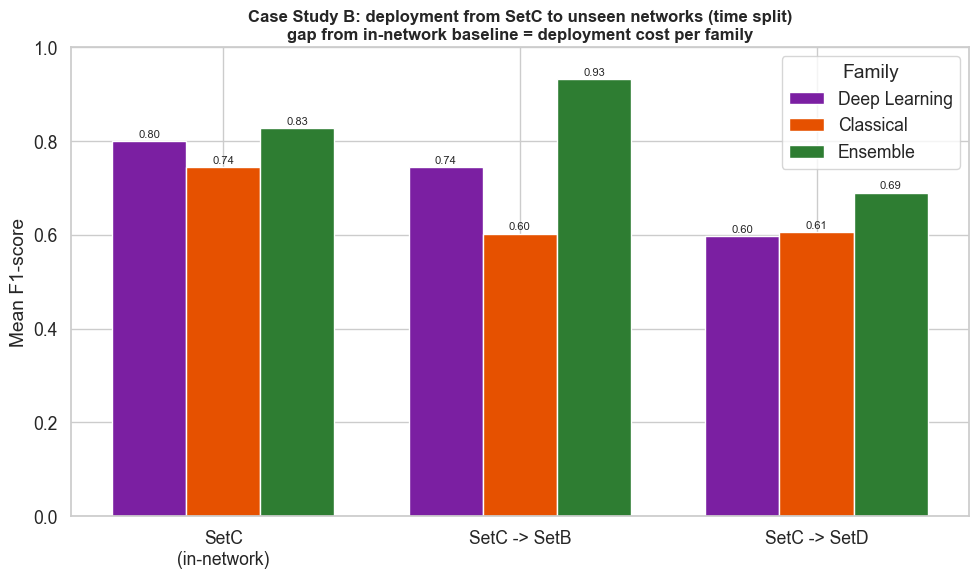

In [16]:
# ── Case Study B figure: deployment transfer per family ─────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
cols = ['SetC in-net', 'SetC->SetB', 'SetC->SetD']
x = np.arange(len(cols)); width = 0.25
for k, fam in enumerate(FAMILIES):
    vals = [csb.set_index('Family').loc[fam, c] for c in cols]
    bars = ax.bar(x + (k - 1) * width, vals, width, label=fam,
                  color=FAM_PALETTE[fam], edgecolor='white')
    for xi, v in zip(x + (k - 1) * width, vals):
        ax.text(xi, v + 0.008, f'{v:.2f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(['SetC\n(in-network)', 'SetC -> SetB', 'SetC -> SetD'])
ax.set_ylabel('Mean F1-score')
ax.set_ylim(0, 1.0)
ax.set_title('Case Study B: deployment from SetC to unseen networks (time split)\n'
             'gap from in-network baseline = deployment cost per family',
             fontsize=12, fontweight='bold')
ax.legend(title='Family')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_cs_deploy_setC.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_cs_deploy_setC.png', dpi=150, bbox_inches='tight')
plt.show()

Figure B shows each family's SetC in-network baseline and its two deployment transfers.
The drop from the leftmost bar to the transfer bars, compared across families, indicates which
family is the safest default when a detector trained on one network must serve others.

The final cell prints a concise evidence summary of the three-way comparison, drawing the
headline numbers from the tables, statistical tests, and both case studies.

In [17]:
# ── Q6 evidence summary ─────────────────────────────────────────────────────
def fam_mean(src, fam, **filt):
    m = (src['family'] == fam)
    for k, v in filt.items():
        m &= (src[k] == v)
    return src[m]['mean_f1'].mean()

print('=' * 74)
print('Q6 EVIDENCE SUMMARY: DL vs Classical vs Ensemble (sequence-based approach)')
print('=' * 74)

print('\n1. OVERALL MEAN F1 BY FAMILY')
for regime, src in [('In-network', avg_in), ('Cross-network', avg_cross)]:
    vals = {f: fam_mean(src, f) for f in FAMILIES}
    best = max(vals, key=vals.get)
    print(f'   {regime:<14}: ' +
          '  '.join(f'{FAM_SHORT[f]}={vals[f]:.4f}' for f in FAMILIES) +
          f'   -> best: {best}')

print('\n2. TIME-SPLIT (deployment-realistic) IN-NETWORK F1 BY FAMILY')
vals = {f: fam_mean(avg_in, f, split='Time split') for f in FAMILIES}
best = max(vals, key=vals.get)
print('   ' + '  '.join(f'{FAM_SHORT[f]}={vals[f]:.4f}' for f in FAMILIES) +
      f'   -> best: {best}')

print('\n3. BEST INDIVIDUAL MODEL')
top_in    = t3.iloc[0]
top_cross = t3.sort_values('Cross-net', ascending=False).iloc[0]
print(f'   In-network : {top_in["Model"]} ({top_in["Family"]}, F1={top_in["In-net (overall)"]:.4f})')
print(f'   Cross-net  : {top_cross["Model"]} ({top_cross["Family"]}, F1={top_cross["Cross-net"]:.4f})')

print('\n4. STATISTICAL SIGNIFICANCE (Holm-corrected, share of strata sig.)')
for regime in ['In-network', 'Cross-network']:
    sub = stat_df[stat_df['eval_type'] == regime]
    pct = 100 * sub['significant'].mean()
    print(f'   {regime:<14}: {pct:.0f}% of pairwise-contrast strata significant')

print('\n5. TRANSFER ROBUSTNESS (mean transfer drop, in-net -> cross-net)')
for f in FAMILIES:
    drop = fam_mean(avg_in, f) - fam_mean(avg_cross, f)
    print(f'   {f:<14}: {drop:+.4f}')

print('\n6. CASE STUDY A - four-month temporal drift (SetA->SetC), temporal drop')
for _, r in csa.iterrows():
    print(f'   {r["Family"]:<14}: {r["Temporal drop"]:+.4f}   (SetA->SetC F1={r["SetA->SetC (time)"]:.4f})')

print('\n7. CASE STUDY B - deployment from SetC, deploy drop')
for _, r in csb.iterrows():
    print(f'   {r["Family"]:<14}: {r["Deploy drop"]:+.4f}   (mean deploy F1={r["Mean deploy"]:.4f})')
print('=' * 74)

Q6 EVIDENCE SUMMARY: DL vs Classical vs Ensemble (sequence-based approach)

1. OVERALL MEAN F1 BY FAMILY
   In-network    : DL=0.8091  Cls=0.7235  Ens=0.8689   -> best: Ensemble
   Cross-network : DL=0.5351  Cls=0.4875  Ens=0.6071   -> best: Ensemble

2. TIME-SPLIT (deployment-realistic) IN-NETWORK F1 BY FAMILY
   DL=0.7783  Cls=0.7057  Ens=0.8158   -> best: Ensemble

3. BEST INDIVIDUAL MODEL
   In-network : lightgbm (Ensemble, F1=0.8717)
   Cross-net  : logistic-regression (Classical, F1=0.6176)

4. STATISTICAL SIGNIFICANCE (Holm-corrected, share of strata sig.)
   In-network    : 42% of pairwise-contrast strata significant
   Cross-network : 17% of pairwise-contrast strata significant

5. TRANSFER ROBUSTNESS (mean transfer drop, in-net -> cross-net)
   Deep Learning : +0.2740
   Classical     : +0.2359
   Ensemble      : +0.2618

6. CASE STUDY A - four-month temporal drift (SetA->SetC), temporal drop
   Deep Learning : +0.0153   (SetA->SetC F1=0.4654)
   Classical     : +0.0817   (Se

In [18]:
# ── Article helpers: number formatting + booktabs table writer (paper style) ──
ARTICLE_FONT = {'font.size': 9, 'axes.titlesize': 9.5, 'axes.labelsize': 9,
                'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
                'legend.fontsize': 8.5, 'pdf.fonttype': 42, 'ps.fonttype': 42}

def fmt4(v):
    return f'{v:.4f}'

def fmts(v):
    return f'{v:+.4f}'

def fmtd(v):
    return f'{v:.3f}'

def fmtp(p):
    return '$<$0.0001' if p < 1e-4 else f'{p:.4f}'

def write_booktabs(path, caption, label, colspec, header, body_rows, midrules_after=()):
    '''Write a LaTeX table in the manuscript style: caption above, booktabs rules.'''
    lines = [r'\begin{table}[htbp]',
             r'\caption{' + caption + '}',
             r'\label{' + label + '}',
             r'\centering',
             r'\small',
             r'\begin{tabular}{' + colspec + '}',
             r'\toprule',
             ' & '.join(header) + r' \\',
             r'\midrule']
    for i, row in enumerate(body_rows):
        lines.append(' & '.join(str(c) for c in row) + r' \\')
        if i in midrules_after:
            lines.append(r'\midrule')
    lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}', '']
    Path(path).write_text('\n'.join(lines))
    print(f'wrote {path}')

def cohens_d_ind_(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return float('nan')
    pooled = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb - 1) * b.std(ddof=1) ** 2)
                     / (na + nb - 2))
    return (a.mean() - b.mean()) / (pooled + 1e-12)

def holm_(pvals):
    pvals = np.asarray(pvals, float)
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (m - rank) * pvals[idx])
        adj[idx] = min(running, 1.0)
    return adj

In [19]:
# ── Article Table 1: overall three-way family comparison (macro F1) ──────────
records = []
for eval_type, sub in [('In-network', avg_in), ('Cross-network', avg_cross)]:
    for task in ['Binary', 'Multiclass']:
        for split in ['Random split', 'Time split']:
            row = {'Eval': eval_type, 'Task': task, 'Split': split.replace(' split', '')}
            for fam in FAMILIES:
                row[fam] = sub[(sub['family'] == fam) & (sub['task'] == task) &
                               (sub['split'] == split)]['mean_f1'].mean()
            row['EnsCls'] = row['Ensemble'] - row['Classical']
            row['EnsDL'] = row['Ensemble'] - row['Deep Learning']
            records.append(row)
t1a = pd.DataFrame(records)

body = []
for _, r in t1a.iterrows():
    best = max(FAMILIES, key=lambda f: r[f])
    cells = [r['Eval'], r['Task'], r['Split']]
    for fam in FAMILIES:
        v = fmt4(r[fam])
        cells.append(r'\textbf{' + v + '}' if fam == best else v)
    cells += [fmts(r['EnsCls']), fmts(r['EnsDL'])]
    body.append(cells)

write_booktabs(
    TAB_DIR / 'q6_article_table1_overall.tex',
    caption=(r'Mean macro F1-score of the three model families under the sequence-based '
             r'approach, broken down by evaluation regime, classification task, and data '
             r'split. Scores are averaged over the models of each family, the networks of '
             r'SCLDDoS2024, and the runs of every configuration; the SetA$\leftrightarrow$SetC '
             r'pair is excluded from the cross-network regime (same physical network, '
             r'different capture period). The best family per row is printed in bold. '
             r'$\Delta$(Ens$-$Cls) and $\Delta$(Ens$-$DL) are the signed gaps of the ensemble '
             r'family over the classical and deep learning families.'),
    label='tab:q6_overall',
    colspec='lllrrrrr',
    header=['Regime', 'Task', 'Split', 'Deep Learning', 'Classical', 'Ensemble',
            r'$\Delta$(Ens$-$Cls)', r'$\Delta$(Ens$-$DL)'],
    body_rows=body,
    midrules_after={3})
print(t1a.round(4).to_string(index=False))

wrote tables/q6_article_table1_overall.tex
         Eval       Task  Split  Deep Learning  Classical  Ensemble  EnsCls  EnsDL
   In-network     Binary Random         0.8852     0.8206    0.9470  0.1263 0.0618
   In-network     Binary   Time         0.8331     0.7836    0.8536  0.0701 0.0205
   In-network Multiclass Random         0.7948     0.6618    0.8969  0.2351 0.1021
   In-network Multiclass   Time         0.7235     0.6279    0.7779  0.1500 0.0545
Cross-network     Binary Random         0.5885     0.5676    0.6407  0.0731 0.0522
Cross-network     Binary   Time         0.6022     0.5473    0.6701  0.1228 0.0679
Cross-network Multiclass Random         0.4642     0.4223    0.5351  0.1128 0.0709
Cross-network Multiclass   Time         0.4854     0.4128    0.5823  0.1695 0.0969


In [20]:
# ── Article Table 2: Holm-corrected pairwise family tests per stratum ────────
records = []
for eval_type, sub_avg in [('In-network', avg_in), ('Cross-network', avg_cross)]:
    for task in ['Binary', 'Multiclass']:
        for split in ['Random split', 'Time split']:
            base = sub_avg[(sub_avg['task'] == task) & (sub_avg['split'] == split)]
            stratum = []
            for fa, fb in CONTRASTS:
                va = base[base['family'] == fa]['mean_f1'].values
                vb = base[base['family'] == fb]['mean_f1'].values
                if len(va) < 2 or len(vb) < 2:
                    continue
                try:
                    _, p = mannwhitneyu(va, vb, alternative='two-sided')
                except ValueError:
                    p = 1.0
                stratum.append({'eval_type': eval_type, 'task': task, 'split': split,
                                'contrast': f'{FAM_SHORT[fa]} vs {FAM_SHORT[fb]}',
                                'diff': va.mean() - vb.mean(),
                                'cohens_d': cohens_d_ind_(va, vb), 'p_raw': p})
            padj = holm_([s['p_raw'] for s in stratum])
            for s, pa in zip(stratum, padj):
                s['p_holm'] = pa
                s['significant'] = pa < 0.05
                records.append(s)
stat_article = pd.DataFrame(records)

body, i = [], 0
mid = set()
for eval_type in ['In-network', 'Cross-network']:
    for task in ['Binary', 'Multiclass']:
        for split in ['Random split', 'Time split']:
            block = stat_article[(stat_article['eval_type'] == eval_type) &
                                 (stat_article['task'] == task) &
                                 (stat_article['split'] == split)]
            for k, (_, r) in enumerate(block.iterrows()):
                lead = [eval_type, task, split.replace(' split', '')] if k == 0 else ['', '', '']
                sig = r'\checkmark' if r['significant'] else ''
                body.append(lead + [r['contrast'], fmts(r['diff']),
                                    fmtd(r['cohens_d']), fmtp(r['p_holm']), sig])
                i += 1
            mid.add(i - 1)
mid.discard(len(body) - 1)

write_booktabs(
    TAB_DIR / 'q6_article_table2_stat_tests.tex',
    caption=(r'Pairwise family contrasts of the sequence-based macro F1-score per '
             r'(regime, task, split) stratum. Each contrast compares the run-averaged '
             r'model$\times$network configurations of one family against the other with the '
             r'two-sided Mann--Whitney U test; configurations are pooled across networks '
             r'because per-network strata leave only three models in the classical and '
             r'ensemble families, for which the minimum attainable two-sided $p$ is 0.1. '
             r"$\Delta$F1 is the signed gap favouring the first family, Cohen's $d$ is "
             r'computed on the pooled distributions, and $p$-values are Holm-corrected '
             r'within each stratum ($\checkmark$: $p<0.05$).'),
    label='tab:q6_stats',
    colspec='llllrrrc',
    header=['Regime', 'Task', 'Split', 'Contrast', r'$\Delta$F1',
            r"Cohen's $d$", r'$p$-value', 'Sig.'],
    body_rows=body,
    midrules_after=mid)
print(stat_article.round(4).to_string(index=False))

wrote tables/q6_article_table2_stat_tests.tex
    eval_type       task        split   contrast    diff  cohens_d  p_raw  p_holm  significant
   In-network     Binary Random split  DL vs Cls  0.0645    0.4898 0.0540  0.1080        False
   In-network     Binary Random split  DL vs Ens -0.0618   -0.6138 0.0590  0.1080        False
   In-network     Binary Random split Ens vs Cls  0.1263    1.1395 0.0043  0.0128         True
   In-network     Binary   Time split  DL vs Cls  0.0496    0.2865 0.0410  0.0820        False
   In-network     Binary   Time split  DL vs Ens -0.0205   -0.1135 0.2351  0.2351        False
   In-network     Binary   Time split Ens vs Cls  0.0701    0.4054 0.0166  0.0497         True
   In-network Multiclass Random split  DL vs Cls  0.1330    0.9469 0.0108  0.0216         True
   In-network Multiclass Random split  DL vs Ens -0.1021   -0.8962 0.0150  0.0216         True
   In-network Multiclass Random split Ens vs Cls  0.2351    2.0613 0.0002  0.0005         True
   I

In [21]:
# ── Article Table 3: per-model ranking with robustness gaps ──────────────────
records = []
for model in ALL_MODELS:
    if model not in avg_in['model'].unique():
        continue
    fam = family_of(model)
    in_all = avg_in[avg_in['model'] == model]['mean_f1'].mean()
    in_rand = avg_in[(avg_in['model'] == model) &
                     (avg_in['split'] == 'Random split')]['mean_f1'].mean()
    in_time = avg_in[(avg_in['model'] == model) &
                     (avg_in['split'] == 'Time split')]['mean_f1'].mean()
    cross_all = avg_cross[avg_cross['model'] == model]['mean_f1'].mean()
    records.append({'Model': model, 'Family': fam, 'in_rand': in_rand, 'in_time': in_time,
                    'cross': cross_all, 'split_drop': in_rand - in_time,
                    'transfer_drop': in_all - cross_all, 'in_all': in_all})
t3a = pd.DataFrame(records).sort_values('in_all', ascending=False).reset_index(drop=True)

MODEL_TEX = {'gru': 'GRU', 'lstm': 'LSTM', 'rnn': 'RNN', 'mlp': 'MLP', 'nn': 'NN',
             'knn': 'k-NN', 'logistic-regression': 'Logistic Regression', 'svm': 'SVM',
             'random-forest': 'Random Forest', 'lightgbm': 'LightGBM', 'xgboost': 'XGBoost'}
best_cross = t3a['cross'].max()
body = []
for _, r in t3a.iterrows():
    cross_txt = fmt4(r['cross'])
    if np.isclose(r['cross'], best_cross):
        cross_txt = r'\textbf{' + cross_txt + '}'
    body.append([MODEL_TEX[r['Model']], r['Family'], fmt4(r['in_rand']), fmt4(r['in_time']),
                 cross_txt, fmt4(r['split_drop']), fmt4(r['transfer_drop'])])

write_booktabs(
    TAB_DIR / 'q6_article_table3_per_model.tex',
    caption=(r'Per-model mean macro F1-score under the sequence-based approach, sorted by '
             r'overall in-network score. In-network scores are reported separately for the '
             r'random and time splits; the cross-network column averages all admissible '
             r'transfer pairs (SetA$\leftrightarrow$SetC excluded). The split drop is the '
             r'random-split score minus the time-split score and measures how much the '
             r'optimistic random split inflates the model; the transfer drop is the overall '
             r'in-network score minus the cross-network score. The best cross-network model '
             r'is printed in bold.'),
    label='tab:q6_per_model',
    colspec='llrrrrr',
    header=['Model', 'Family', 'In-net (rand)', 'In-net (time)', 'Cross-net',
            'Split drop', 'Transfer drop'],
    body_rows=body)
print(t3a.round(4).to_string(index=False))

wrote tables/q6_article_table3_per_model.tex
              Model        Family  in_rand  in_time  cross  split_drop  transfer_drop  in_all
           lightgbm      Ensemble   0.9233   0.8202 0.6131      0.1031         0.2586  0.8717
            xgboost      Ensemble   0.9214   0.8183 0.5993      0.1031         0.2705  0.8698
      random-forest      Ensemble   0.9212   0.8089 0.6087      0.1123         0.2564  0.8650
                gru Deep Learning   0.8843   0.7948 0.5979      0.0895         0.2417  0.8396
                rnn Deep Learning   0.8751   0.7902 0.5853      0.0849         0.2473  0.8327
               lstm Deep Learning   0.8732   0.7850 0.4992      0.0882         0.3299  0.8291
                knn     Classical   0.8054   0.7613 0.4665      0.0441         0.3168  0.7833
                 nn Deep Learning   0.7808   0.7637 0.4337      0.0171         0.3385  0.7722
                mlp Deep Learning   0.7864   0.7577 0.5592      0.0287         0.2129  0.7721
logistic-regres

In [22]:
# ── Article Table 4: case studies A (temporal drift) and B (deployment) ──────
tempo = f1[(f1['train_set'] == 'SetA') & (f1['test_set'].isin(['SetA', 'SetC']))].copy()
tempo_avg = (tempo.groupby(['model', 'family', 'task', 'split', 'test_set'],
                           as_index=False)['value'].mean()
                  .rename(columns={'value': 'mean_f1'}))

def _rung(fam, split, test_set):
    return tempo_avg[(tempo_avg['family'] == fam) & (tempo_avg['split'] == split) &
                     (tempo_avg['test_set'] == test_set)]['mean_f1'].mean()

csa_rows = []
for fam in FAMILIES:
    r_in = _rung(fam, 'Random split', 'SetA')
    t_in = _rung(fam, 'Time split', 'SetA')
    t_gap = _rung(fam, 'Time split', 'SetC')
    csa_rows.append({'Family': fam, 'rand_in': r_in, 'time_in': t_in, 'gap': t_gap,
                     'temporal_drop': t_in - t_gap, 'total_drop': r_in - t_gap})
csa_a = pd.DataFrame(csa_rows)

dep = f1[(f1['train_set'] == 'SetC') & (f1['test_set'].isin(['SetC', 'SetB', 'SetD'])) &
         (f1['split'] == 'Time split')].copy()
dep_avg = (dep.groupby(['model', 'family', 'test_set'], as_index=False)['value'].mean()
              .rename(columns={'value': 'mean_f1'}))

def _dep(fam, test_set):
    return dep_avg[(dep_avg['family'] == fam) &
                   (dep_avg['test_set'] == test_set)]['mean_f1'].mean()

csb_rows = []
for fam in FAMILIES:
    base = _dep(fam, 'SetC'); b = _dep(fam, 'SetB'); d = _dep(fam, 'SetD')
    csb_rows.append({'Family': fam, 'base': base, 'to_b': b, 'to_d': d,
                     'deploy': np.mean([b, d]), 'deploy_drop': base - np.mean([b, d])})
csb_a = pd.DataFrame(csb_rows)

body = []
body.append([r'\multicolumn{6}{l}{\emph{Case study A: temporal drift on a fixed network, '
             r'SetA $\rightarrow$ SetC (time split, $\approx$4-month gap)}}'])
body.append(['Family', 'Random in-net', 'Time in-net', r'SetA$\to$SetC',
             'Temporal drop', 'Total drop'])
for _, r in csa_a.iterrows():
    body.append([r['Family'], fmt4(r['rand_in']), fmt4(r['time_in']), fmt4(r['gap']),
                 fmts(r['temporal_drop']), fmts(r['total_drop'])])
body.append([r'\multicolumn{6}{l}{\emph{Case study B: deployment from the strongest source, '
             r'SetC $\rightarrow$ \{SetB, SetD\} (time split)}}'])
body.append(['Family', 'SetC in-net', r'SetC$\to$SetB', r'SetC$\to$SetD',
             'Mean deploy', 'Deploy drop'])
for _, r in csb_a.iterrows():
    body.append([r['Family'], fmt4(r['base']), fmt4(r['to_b']), fmt4(r['to_d']),
                 fmt4(r['deploy']), fmts(r['deploy_drop'])])

write_booktabs(
    TAB_DIR / 'q6_article_table4_case_studies.tex',
    caption=(r'Family-level case studies under the sequence-based approach. Case study A '
             r'trains on SetA and evaluates on SetC, the same physical network captured '
             r'roughly four months later, so the SetA$\to$SetC column isolates long-horizon '
             r'temporal drift from network-domain shift; the temporal drop is the time-split '
             r'in-network score minus the SetA$\to$SetC score and the total drop starts from '
             r'the optimistic random split. Case study B trains on SetC, the strongest '
             r'cross-network source identified in Q4, and deploys to SetB and SetD under the '
             r'time split; SetA is excluded as a target because it is the same physical '
             r'network as SetC. All values are mean macro F1-scores over the models of each '
             r'family, tasks, and runs.'),
    label='tab:q6_case_studies',
    colspec='lrrrrr',
    header=[r'\multicolumn{6}{c}{Case studies by model family (mean macro F1-score)}'],
    body_rows=body,
    midrules_after={0, 1, 4, 5, 6})
print(csa_a.round(4).to_string(index=False))
print(csb_a.round(4).to_string(index=False))

wrote tables/q6_article_table4_case_studies.tex
       Family  rand_in  time_in    gap  temporal_drop  total_drop
Deep Learning   0.6541   0.4807 0.4654         0.0153      0.1887
    Classical   0.5292   0.4602 0.3785         0.0817      0.1507
     Ensemble   0.8409   0.5283 0.4880         0.0403      0.3529
       Family   base   to_b   to_d  deploy  deploy_drop
Deep Learning 0.7996 0.7447 0.5977  0.6712       0.1284
    Classical 0.7439 0.6026 0.6052  0.6039       0.1400
     Ensemble 0.8270 0.9321 0.6901  0.8111       0.0158


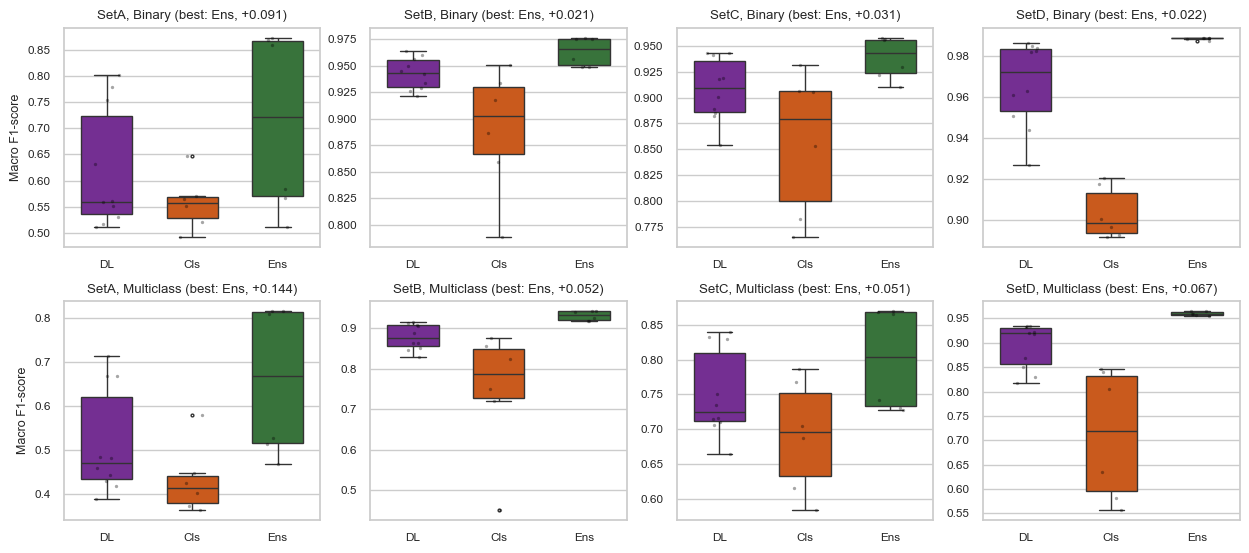

In [23]:
# ── Article Figure 1: in-network family distributions per network and task ───
with plt.rc_context(ARTICLE_FONT):
    fig, axes = plt.subplots(2, 4, figsize=(12.5, 5.6), sharey=False)
    for col, net in enumerate(NETWORKS):
        for row, task in enumerate(['Binary', 'Multiclass']):
            ax = axes[row, col]
            sub = avg_in[(avg_in['test_set'] == net) & (avg_in['task'] == task)]
            sns.boxplot(data=sub, x='family', y='mean_f1', hue='family',
                        palette=FAM_PALETTE, order=FAMILIES, ax=ax,
                        width=0.6, fliersize=2, legend=False)
            sns.stripplot(data=sub, x='family', y='mean_f1', order=FAMILIES,
                          ax=ax, color='black', size=2.4, alpha=0.35, jitter=0.15)
            means = {f: sub[sub['family'] == f]['mean_f1'].mean() for f in FAMILIES}
            best = max(means, key=means.get)
            margin = means[best] - sorted(means.values())[-2]
            ax.set_title(f'{net}, {task} (best: {FAM_SHORT[best]}, +{margin:.3f})')
            ax.set_xlabel('')
            ax.set_ylabel('Macro F1-score' if col == 0 else '')
            ax.set_xticks(range(len(FAMILIES)))
            ax.set_xticklabels(['DL', 'Cls', 'Ens'])
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'q6_article_fig1_innet_families.pdf', bbox_inches='tight')
    plt.savefig(FIG_DIR / 'q6_article_fig1_innet_families.png', dpi=150, bbox_inches='tight')
    plt.show()

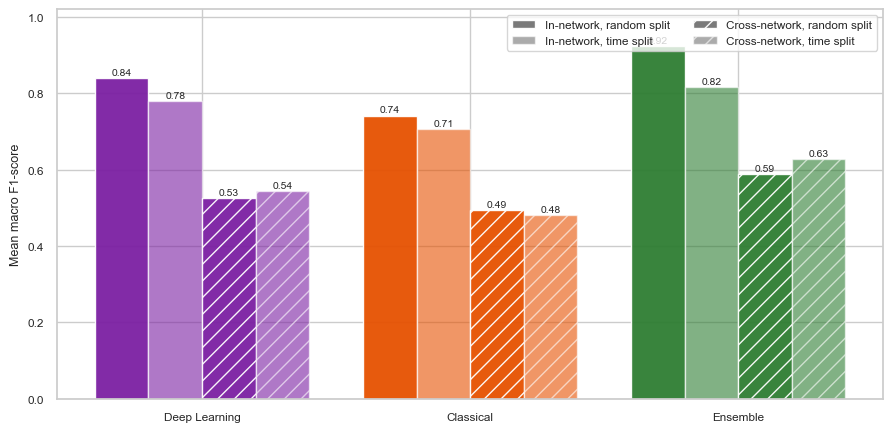

In [24]:
# ── Article Figure 2: family means across regimes and splits ─────────────────
with plt.rc_context(ARTICLE_FONT):
    fig, ax = plt.subplots(figsize=(9, 4.4))
    bar_specs = [('In-network, random split', avg_in, 'Random split', 0),
                 ('In-network, time split', avg_in, 'Time split', 1),
                 ('Cross-network, random split', avg_cross, 'Random split', 2),
                 ('Cross-network, time split', avg_cross, 'Time split', 3)]
    x = np.arange(len(FAMILIES)); width = 0.2
    hatches = ['', '', '//', '//']
    alphas = [0.95, 0.6, 0.95, 0.6]
    for label, src, split, k in bar_specs:
        vals = [src[(src['family'] == fam) & (src['split'] == split)]['mean_f1'].mean()
                for fam in FAMILIES]
        ax.bar(x + (k - 1.5) * width, vals, width, label=label,
               color=[FAM_PALETTE[f] for f in FAMILIES],
               alpha=alphas[k], hatch=hatches[k], edgecolor='white')
        for xi, v in zip(x + (k - 1.5) * width, vals):
            ax.text(xi, v + 0.008, f'{v:.2f}', ha='center', fontsize=7.5)
    ax.set_xticks(x); ax.set_xticklabels(FAMILIES)
    ax.set_ylabel('Mean macro F1-score')
    ax.set_ylim(0, 1.02)
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor='0.45', alpha=a, hatch=h,
                             edgecolor='white') for (_, _, _, k), a, h
               in zip(bar_specs, alphas, hatches)]
    ax.legend(handles, [s[0] for s in bar_specs], ncol=2, loc='upper right', frameon=True)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'q6_article_fig2_regime_families.pdf', bbox_inches='tight')
    plt.savefig(FIG_DIR / 'q6_article_fig2_regime_families.png', dpi=150, bbox_inches='tight')
    plt.show()

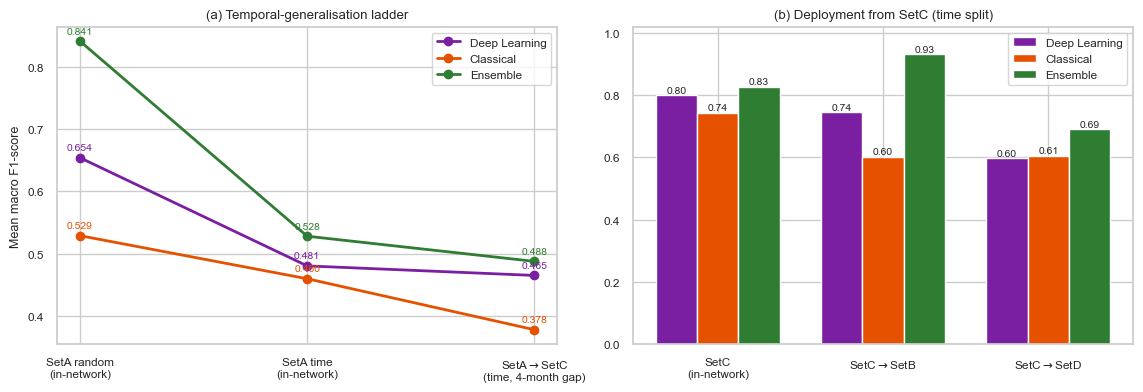

In [25]:
# ── Article Figure 3: case studies A (ladder) and B (deployment) ─────────────
with plt.rc_context(ARTICLE_FONT):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))

    ax = axes[0]
    rungs = ['rand_in', 'time_in', 'gap']
    xs = np.arange(len(rungs))
    for _, r in csa_a.iterrows():
        ax.plot(xs, [r[c] for c in rungs], marker='o', markersize=6, lw=2,
                color=FAM_PALETTE[r['Family']], label=r['Family'])
        for xi, c in zip(xs, rungs):
            ax.text(xi, r[c] + 0.012, f'{r[c]:.3f}', ha='center', fontsize=7.5,
                    color=FAM_PALETTE[r['Family']])
    ax.set_xticks(xs)
    ax.set_xticklabels(['SetA random\n(in-network)', 'SetA time\n(in-network)',
                        'SetA$\\rightarrow$SetC\n(time, 4-month gap)'])
    ax.set_ylabel('Mean macro F1-score')
    ax.set_title('(a) Temporal-generalisation ladder')
    ax.legend(frameon=True)

    ax = axes[1]
    cols = ['base', 'to_b', 'to_d']
    x = np.arange(len(cols)); width = 0.25
    for k, fam in enumerate(FAMILIES):
        vals = [csb_a.set_index('Family').loc[fam, c] for c in cols]
        ax.bar(x + (k - 1) * width, vals, width, label=fam,
               color=FAM_PALETTE[fam], edgecolor='white')
        for xi, v in zip(x + (k - 1) * width, vals):
            ax.text(xi, v + 0.008, f'{v:.2f}', ha='center', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['SetC\n(in-network)', 'SetC$\\rightarrow$SetB', 'SetC$\\rightarrow$SetD'])
    ax.set_ylim(0, 1.02)
    ax.set_title('(b) Deployment from SetC (time split)')
    ax.legend(frameon=True)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'q6_article_fig3_case_studies.pdf', bbox_inches='tight')
    plt.savefig(FIG_DIR / 'q6_article_fig3_case_studies.png', dpi=150, bbox_inches='tight')
    plt.show()

In [26]:
# ── Console recap of the numbers cited in the manuscript text ────────────────
print('Ensemble best in all 8 strata:',
      all(max(FAMILIES, key=lambda f: r[f]) == 'Ensemble' for _, r in t1a.iterrows()))
per_net_best = []
for net in NETWORKS:
    for task in ['Binary', 'Multiclass']:
        means = {f: avg_in[(avg_in['test_set'] == net) & (avg_in['family'] == f) &
                           (avg_in['task'] == task)]['mean_f1'].mean() for f in FAMILIES}
        per_net_best.append(max(means, key=means.get))
print('Ensemble best in all 8 network x task cells:',
      all(b == 'Ensemble' for b in per_net_best))
print('Significant strata (in-net):',
      stat_article[stat_article.eval_type == 'In-network']['significant'].mean())
print('Significant strata (cross):',
      stat_article[stat_article.eval_type == 'Cross-network']['significant'].mean())

Ensemble best in all 8 strata: True
Ensemble best in all 8 network x task cells: True
Significant strata (in-net): 0.4166666666666667
Significant strata (cross): 0.16666666666666666
